# Diffractive Lens Optimization — Focusing a Plane Wave

This notebook is the **entry point for the lens-design family** in the example set. It optimizes a
single **phase-only diffractive lens** so a uniform plane wave forms a bright focal spot after free-space propagation.

### Assumes you know

- basic coherent propagation and phase delay,
- how intensity is computed from a propagated field, and
- the idea of optimizing a differentiable optical system end to end.

### New ideas in this notebook

- how to impose a circular aperture on a trainable phase element,
- how a focal-spot loss turns wavefront design into a scalar optimization objective,
- why the phase is bounded to $[0, 2\pi]$ during training, and
- how the learned phase compares with the analytical hyperbolic phase of an ideal focusing lens.

### Where to go next

Continue to [sensitivity_analysis.ipynb](sensitivity_analysis.ipynb) for measurement/design analysis
of a lens, or to [metaatom_optimization.ipynb](metaatom_optimization.ipynb) for the same focusing
task under a fabrication-library constraint.


## 0  Imports

This notebook uses JAX and Optax for optimization, Matplotlib for diagnostics, and `fouriax`
primitives for the field, masks, propagation layer, and focal-spot loss.


In [1]:
from __future__ import annotations

import argparse
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

import fouriax as fx

import os
from pathlib import Path as _Path
%matplotlib inline

REPO_ROOT = fx.utils.find_repo_root(_Path.cwd())
if _Path.cwd() != REPO_ROOT:
    os.chdir(REPO_ROOT)


## 1  Paths and Parameters

The parameters define the simulation grid, wavelength, propagation distance, aperture diameter, and
optimization workload. Together they specify both the optical problem and how tightly the focusing
objective is evaluated around the target pixel.


In [2]:
ARTIFACTS_DIR = Path('artifacts')
PLOT_PATH = ARTIFACTS_DIR / "lens_optimization_overview.png"
SUMMARY_PATH = ARTIFACTS_DIR / "lens_opt_summary.json"

SEED = 0
GRID_N = 64
GRID_DX_UM = 1.0
WAVELENGTH_UM = 0.532
DISTANCE_UM = 1000.0
APERTURE_DIAMETER_UM = 48.0
WINDOW_PX = 2
LR = 0.05
STEPS = 60
PLOT = True


## 2  Helper Functions

The helper builds a binary circular aperture on the simulation grid. This separates two roles in the
design:

- the **phase mask** controls the wavefront, and
- the **aperture** limits which pixels actually transmit light.

That distinction matters in later notebooks where the trainable surface is no longer an unconstrained
phase map.


In [3]:
def circular_aperture(grid: fx.Grid, diameter_um: float) -> jnp.ndarray:
    x, y = grid.spatial_grid()
    r2 = x * x + y * y
    radius = diameter_um / 2.0
    return (r2 <= radius * radius).astype(jnp.float32)


## 3  Setup

We illuminate the aperture with a plane wave, choose the center pixel as the desired focus, and
build an optical module consisting of

$$
\text{phase mask}
\;\rightarrow\;
\text{aperture}
\;\rightarrow\;
\text{free-space propagation}.
$$

The trainable parameter is an unconstrained array that is mapped through a sigmoid to a bounded phase
mask, ensuring the learned optic remains phase-only throughout optimization.


In [4]:
grid = fx.Grid.from_extent(nx=GRID_N, ny=GRID_N, dx_um=GRID_DX_UM, dy_um=GRID_DX_UM)
spectrum = fx.Spectrum.from_scalar(WAVELENGTH_UM)
field_in = fx.Field.plane_wave(grid=grid, spectrum=spectrum)

aperture = circular_aperture(grid, diameter_um=APERTURE_DIAMETER_UM)
target_xy = (grid.nx // 2, grid.ny // 2)
propagator = fx.plan_propagation(
    mode="auto",
    grid=grid,
    spectrum=spectrum,
    distance_um=DISTANCE_UM,
)

def build_module(raw_phase_map: jnp.ndarray) -> fx.OpticalModule:
    phase_limited = 2.0 * jnp.pi * jax.nn.sigmoid(raw_phase_map)
    return fx.OpticalModule(
        layers=(
            fx.PhaseMask(phase_map_rad=phase_limited[None, :, :]),
            fx.AmplitudeMask(amplitude_map=aperture[None, :, :]),
            propagator,
        )
    )


## 4  Loss Function and Optimization

The loss is `fx.optim.focal_spot_loss`, which rewards intensity concentrated near the target pixel
inside a configurable square window. This turns the wave-optics design problem into a single scalar
objective that Adam can optimize directly.

The optimizer keeps the best phase map encountered during training rather than assuming the final
iterate is the best one.


In [5]:
def loss_fn(raw_phase_map: jnp.ndarray) -> jnp.ndarray:
    module = build_module(raw_phase_map)
    intensity = module.forward(field_in).intensity()
    return fx.optim.focal_spot_loss(
        intensity=intensity,
        target_xy=target_xy,
        window_px=WINDOW_PX,
    )

key = jax.random.PRNGKey(SEED)
phase_map = 0.1 * jax.random.normal(key, (grid.ny, grid.nx))

optimizer = optax.adam(LR)
result = fx.optim.optimize_optical_module(
    init_params=phase_map,
    build_module=build_module,
    loss_fn=loss_fn,
    optimizer=optimizer,
    steps=STEPS,
    log_every=20,
)
final_phase_limited = 2.0 * jnp.pi * jax.nn.sigmoid(result.best_params)
final_intensity = np.asarray(result.best_module.forward(field_in).intensity())[0]
optimized_profile = final_intensity[target_xy[1], :]


step=000 loss=0.944947


step=020 loss=0.847495


step=040 loss=0.838609


step=059 loss=0.835569


## 5  Evaluation

We compare the optimized lens against an analytical hyperbolic-phase reference with the same focal
distance. The ideal reference phase used in the code is

$$
\phi_{\mathrm{ref}}(x,y)
= -k\left(\sqrt{x^2 + y^2 + f^2} - f\right),
\qquad k = \frac{2\pi}{\lambda},
$$

which is the hyperbolic optical-path-delay profile for focusing a plane wave to distance $f$.
The comparison is intentionally simple: if the learned lens is behaving sensibly, its focal
spot and center-row intensity profile should resemble the reference solution even though the training
objective only asked for a bright focus.


In [6]:
x_um, y_um = grid.spatial_grid()
wavelength_um = float(spectrum.wavelengths_um[0])
k = 2.0 * jnp.pi / wavelength_um
hyperbolic_phase = -k * (jnp.sqrt(x_um * x_um + y_um * y_um + DISTANCE_UM**2) - DISTANCE_UM)
reference_module = fx.OpticalModule(
    layers=(
        fx.PhaseMask(phase_map_rad=hyperbolic_phase[None, :, :]),
        fx.AmplitudeMask(amplitude_map=aperture[None, :, :]),
        propagator,
    )
)
reference_intensity = np.asarray(reference_module.forward(field_in).intensity())[0]
reference_profile = reference_intensity[target_xy[1], :]


## 6  Plot Results

The overview figure combines optimization dynamics, the learned phase pattern, the 2D focal spot, and
a 1D profile comparison against the analytical lens.

The key interpretation is not that the learned phase must numerically equal the hyperbolic phase at
every pixel, but that it should produce a similarly concentrated focus at the target location.


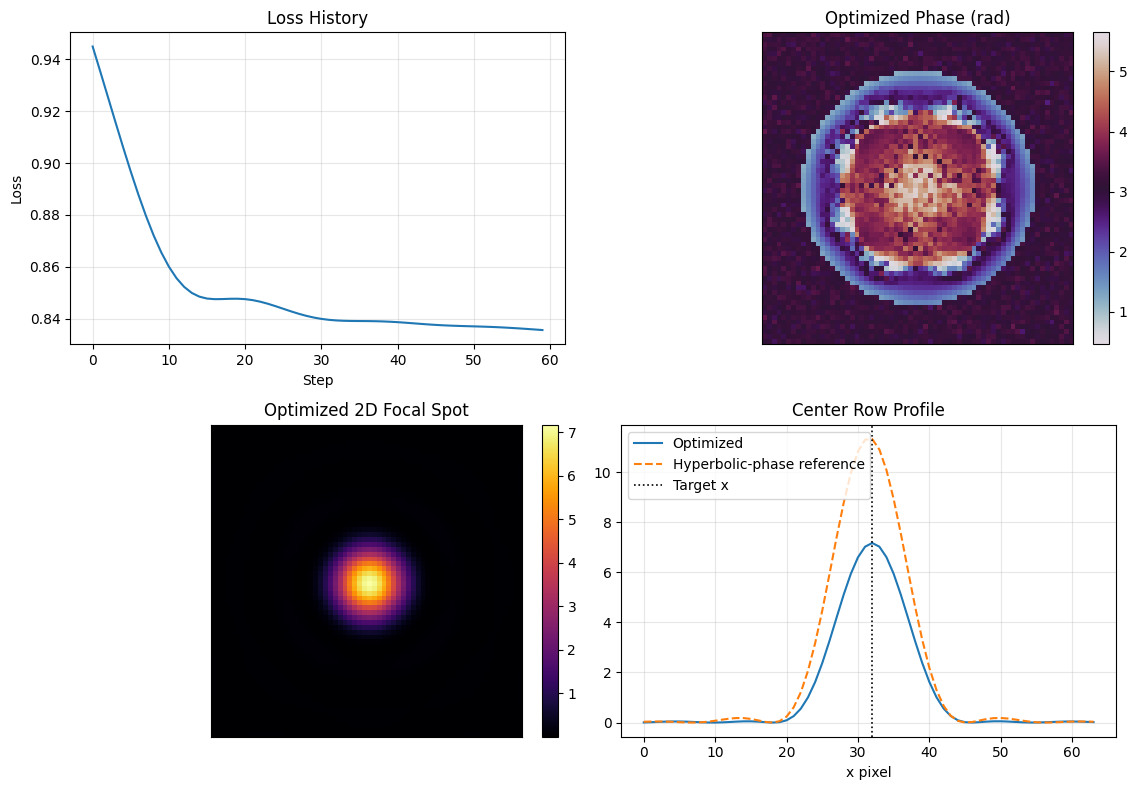

saved: artifacts/lens_optimization_overview.png


In [7]:
if PLOT:
    optimized_phase = np.asarray(final_phase_limited)
    fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0))

    axes[0, 0].plot(result.history)
    axes[0, 0].set_title("Loss History")
    axes[0, 0].set_xlabel("Step")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].grid(alpha=0.3)

    phase_im = axes[0, 1].imshow(optimized_phase, cmap="twilight")
    axes[0, 1].set_title("Optimized Phase (rad)")
    axes[0, 1].set_xticks([])
    axes[0, 1].set_yticks([])
    plt.colorbar(phase_im, ax=axes[0, 1], fraction=0.046, pad=0.04)

    focus_im = axes[1, 0].imshow(final_intensity, cmap="inferno")
    axes[1, 0].set_title("Optimized 2D Focal Spot")
    axes[1, 0].set_xticks([])
    axes[1, 0].set_yticks([])
    plt.colorbar(focus_im, ax=axes[1, 0], fraction=0.046, pad=0.04)

    axes[1, 1].plot(optimized_profile, label="Optimized")
    axes[1, 1].plot(reference_profile, label="Hyperbolic-phase reference", linestyle="--")
    axes[1, 1].axvline(
        target_xy[0], color="black", linestyle=":", linewidth=1.2, label="Target x"
    )
    axes[1, 1].set_title("Center Row Profile")
    axes[1, 1].set_xlabel("x pixel")
    axes[1, 1].grid(alpha=0.3)
    axes[1, 1].legend()

    fig.tight_layout()
    fig.savefig(PLOT_PATH, dpi=150)
    plt.show()
    print(f"saved: {PLOT_PATH}")
